# Codon Table & Amino Acid Mutational Proximity

Two visualizations exploring the genetic code:
1. The standard codon table (4x4x4 grid), color-coded by amino acid property group.
2. A 20x20 heatmap and network graph showing single-nucleotide substitution connectivity between amino acid pairs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, Rectangle
from matplotlib.transforms import blended_transform_factory
from collections import defaultdict
import networkx as nx
from Bio.Data import CodonTable

# Standard genetic code (RNA codons)
dna_table = CodonTable.standard_dna_table

codon_to_aa = {}
for codon, aa in dna_table.forward_table.items():
    codon_to_aa[codon.replace("T", "U")] = aa
for codon in dna_table.stop_codons:
    codon_to_aa[codon.replace("T", "U")] = "*"

# Reverse mapping: AA -> list of codons
aa_to_codons = defaultdict(list)
for codon, aa in codon_to_aa.items():
    aa_to_codons[aa].append(codon)
for aa in aa_to_codons:
    aa_to_codons[aa].sort()

# Amino acid property groups (same as blosum_heatmap.ipynb)
groups = [
    ("Hydrophobic",     list("AVILMFYW")),
    ("Polar uncharged", list("STNQ")),
    ("Special",         list("CGP")),
    ("Positive",        list("RHK")),
    ("Negative",        list("DE")),
]
group_colors = ["#E8546D", "#F4A259", "#F7DC6F", "#ABEBC6", "#1E8449"]

# Map AA -> group color
aa_to_color = {}
for (name, members), color in zip(groups, group_colors):
    for aa in members:
        aa_to_color[aa] = color
aa_to_color["*"] = "#CCCCCC"

# 3-letter names
aa_names = {
    "A": "Ala", "R": "Arg", "N": "Asn", "D": "Asp", "C": "Cys",
    "E": "Glu", "Q": "Gln", "G": "Gly", "H": "His", "I": "Ile",
    "L": "Leu", "K": "Lys", "M": "Met", "F": "Phe", "P": "Pro",
    "S": "Ser", "T": "Thr", "W": "Trp", "Y": "Tyr", "V": "Val",
    "*": "Stop",
}

print(f"{len(codon_to_aa)} codons loaded")
for aa in sorted(aa_to_codons):
    print(f"  {aa} ({aa_names.get(aa, aa)}): {', '.join(aa_to_codons[aa])}")

64 codons loaded
  * (Stop): UAA, UAG, UGA
  A (Ala): GCA, GCC, GCG, GCU
  C (Cys): UGC, UGU
  D (Asp): GAC, GAU
  E (Glu): GAA, GAG
  F (Phe): UUC, UUU
  G (Gly): GGA, GGC, GGG, GGU
  H (His): CAC, CAU
  I (Ile): AUA, AUC, AUU
  K (Lys): AAA, AAG
  L (Leu): CUA, CUC, CUG, CUU, UUA, UUG
  M (Met): AUG
  N (Asn): AAC, AAU
  P (Pro): CCA, CCC, CCG, CCU
  Q (Gln): CAA, CAG
  R (Arg): AGA, AGG, CGA, CGC, CGG, CGU
  S (Ser): AGC, AGU, UCA, UCC, UCG, UCU
  T (Thr): ACA, ACC, ACG, ACU
  V (Val): GUA, GUC, GUG, GUU
  W (Trp): UGG
  Y (Tyr): UAC, UAU


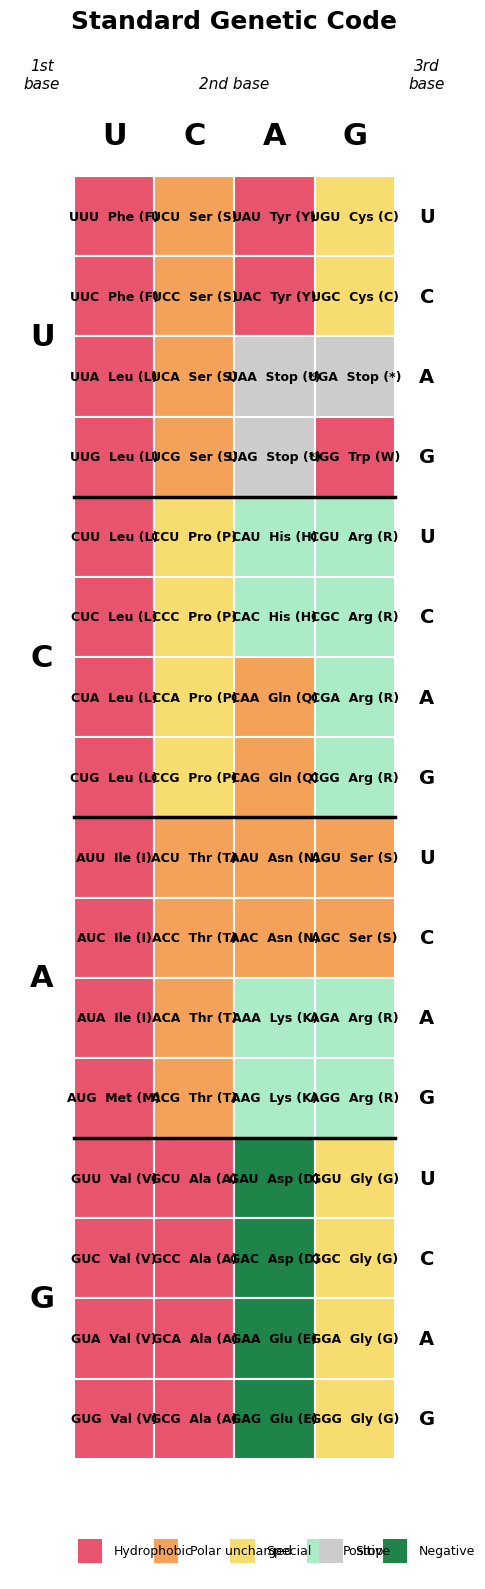

In [2]:
bases = ["U", "C", "A", "G"]

fig, ax = plt.subplots(figsize=(14, 16))
ax.set_xlim(-0.8, 4.8)
ax.set_ylim(-1.5, 17.5)
ax.invert_yaxis()
ax.set_aspect("equal")
ax.axis("off")

for i, b1 in enumerate(bases):        # 1st position (row groups)
    for k, b3 in enumerate(bases):     # 3rd position (sub-rows)
        row = i * 4 + k
        for j, b2 in enumerate(bases): # 2nd position (columns)
            codon = b1 + b2 + b3
            aa = codon_to_aa[codon]
            color = aa_to_color[aa]

            rect = Rectangle((j, row), 1, 1,
                              facecolor=color, edgecolor="white", linewidth=1.5)
            ax.add_patch(rect)

            label = f"{codon}  {aa_names[aa]} ({aa})"
            ax.text(j + 0.5, row + 0.5, label,
                    ha="center", va="center", fontsize=9, fontweight="bold")

# 1st base labels (left margin)
for i, b1 in enumerate(bases):
    ax.text(-0.4, i * 4 + 2, b1, ha="center", va="center",
            fontsize=22, fontweight="bold")

# 2nd base labels (top margin)
for j, b2 in enumerate(bases):
    ax.text(j + 0.5, -0.5, b2, ha="center", va="center",
            fontsize=22, fontweight="bold")

# 3rd base labels (right margin)
for i in range(4):
    for k, b3 in enumerate(bases):
        ax.text(4.4, i * 4 + k + 0.5, b3, ha="center", va="center",
                fontsize=14, fontweight="bold")

# Axis position labels
ax.text(-0.4, -1.1, "1st\nbase", ha="center", fontsize=11, fontstyle="italic")
ax.text(2.0, -1.1, "2nd base", ha="center", fontsize=11, fontstyle="italic")
ax.text(4.4, -1.1, "3rd\nbase", ha="center", fontsize=11, fontstyle="italic")

# Group boundary lines between 1st-base groups
for i in range(1, 4):
    ax.plot([0, 4], [i * 4, i * 4], color="black", linewidth=2.5, clip_on=False)

ax.set_title("Standard Genetic Code", fontsize=18, fontweight="bold", pad=20)

# Legend
legend_y = 17.0
for idx, ((name, _), color) in enumerate(zip(groups, group_colors)):
    x = 0.05 + idx * 0.95
    ax.add_patch(Rectangle((x, legend_y), 0.3, 0.3,
                            facecolor=color, edgecolor="none", clip_on=False))
    ax.text(x + 0.45, legend_y + 0.15, name, ha="left", va="center", fontsize=9)

ax.add_patch(Rectangle((0.05 + 5 * 0.6, legend_y), 0.3, 0.3,
                        facecolor="#CCCCCC", edgecolor="none", clip_on=False))
ax.text(0.05 + 5 * 0.6 + 0.45, legend_y + 0.15, "Stop", ha="left", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [3]:
def hamming1(c1, c2):
    """True if two codons differ by exactly one nucleotide."""
    return sum(a != b for a, b in zip(c1, c2)) == 1

# 20 standard amino acids in grouped order
group_order = [aa for _, members in groups for aa in members]
aa_index = {aa: i for i, aa in enumerate(group_order)}
n = len(group_order)

# Build 20x20 single-nucleotide substitution count matrix
sub_matrix = np.zeros((n, n), dtype=int)
codons = list(codon_to_aa.keys())

for c1 in codons:
    aa1 = codon_to_aa[c1]
    if aa1 == "*":
        continue
    for c2 in codons:
        aa2 = codon_to_aa[c2]
        if aa2 == "*":
            continue
        if hamming1(c1, c2):
            sub_matrix[aa_index[aa1], aa_index[aa2]] += 1

df_sub = pd.DataFrame(sub_matrix, index=group_order, columns=group_order)

print(f"Total single-nt substitution pairs (excl. stop): {sub_matrix.sum()}")
print(f"Synonymous (diagonal): {np.trace(sub_matrix)}")
print(f"Non-synonymous (off-diagonal): {sub_matrix.sum() - np.trace(sub_matrix)}")
print(f"Symmetric check: {np.allclose(sub_matrix, sub_matrix.T)}")
print(f"\nMax off-diagonal: {(sub_matrix - np.diag(np.diag(sub_matrix))).max()}")
print(f"Zero off-diagonal pairs: {sum(1 for i in range(n) for j in range(i+1, n) if sub_matrix[i,j] == 0)}")

df_sub

Total single-nt substitution pairs (excl. stop): 526
Synonymous (diagonal): 134
Non-synonymous (off-diagonal): 392
Symmetric check: True

Max off-diagonal: 6
Zero off-diagonal pairs: 115


,A,V,I,L,M,F,Y,W,S,T,N,Q,C,G,P,R,H,K,D,E
A,12,4,0,0,0,0,0,0,4,4,0,0,0,4,4,0,0,0,2,2
V,4,12,3,6,1,2,0,0,0,0,0,0,0,4,0,0,0,0,2,2
I,0,3,6,4,3,2,0,0,2,3,2,0,0,0,0,1,0,1,0,0
L,0,6,4,18,2,6,0,1,2,0,0,2,0,0,4,4,2,0,0,0
M,0,1,3,2,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
F,0,2,2,6,0,2,2,0,2,0,0,0,2,0,0,0,0,0,0,0
Y,0,0,0,0,0,2,2,0,2,0,2,0,2,0,0,0,2,0,2,0
W,0,0,0,1,0,0,0,0,1,0,0,0,2,1,0,2,0,0,0,0
S,4,0,2,2,0,2,2,1,14,6,2,0,4,2,4,6,0,0,0,0
T,4,0,3,0,1,0,0,0,6,12,2,0,0,0,4,2,0,2,0,0


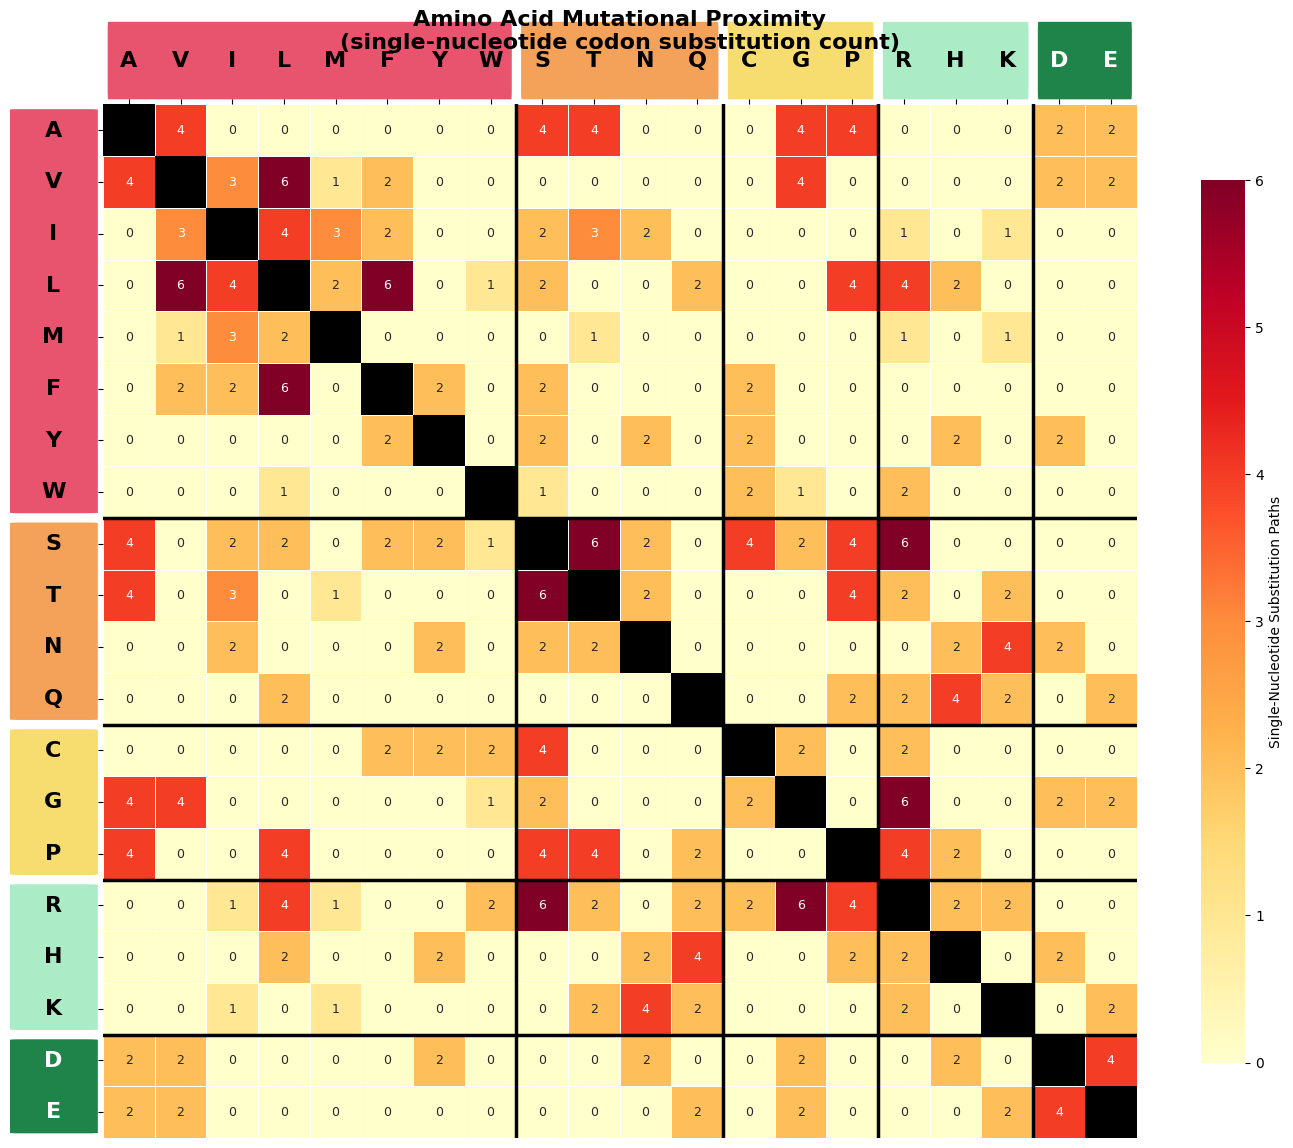

In [4]:
group_boundaries = np.cumsum([len(m) for _, m in groups])[:-1]
starts = [0] + list(group_boundaries)
sizes = [len(m) for _, m in groups]
mask = np.eye(n, dtype=bool)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    df_sub,
    annot=True,
    fmt="d",
    mask=mask,
    cmap="YlOrRd",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Single-Nucleotide Substitution Paths", "shrink": 0.8},
    ax=ax,
    annot_kws={"size": 9},
)

# Black diagonal
for i in range(n):
    ax.add_patch(Rectangle((i, i), 1, 1, facecolor="black", edgecolor="none"))

# Group boundary lines
for b in group_boundaries:
    ax.axhline(y=b, color="black", linewidth=2.5)
    ax.axvline(x=b, color="black", linewidth=2.5)

# Move x-axis to top, hide default labels
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_title("Amino Acid Mutational Proximity\n(single-nucleotide codon substitution count)",
             fontsize=16, fontweight="bold", pad=40)

# Y-axis (left) highlight bands
trans_y = blended_transform_factory(ax.transAxes, ax.transData)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (-0.08, start + 0.1), 0.065, size - 0.2,
        transform=trans_y, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# X-axis (top) highlight bands
trans_x = blended_transform_factory(ax.transData, ax.transAxes)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (start + 0.1, 1.015), size - 0.2, 0.055,
        transform=trans_x, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# Custom tick labels on top of bands
for i, aa in enumerate(group_order):
    color = "white" if i >= starts[-1] else "black"
    ax.text(-0.048, i + 0.5, aa,
            transform=trans_y, ha="center", va="center",
            fontsize=16, fontweight="bold", color=color, clip_on=False)
    ax.text(i + 0.5, 1.042, aa,
            transform=trans_x, ha="center", va="center",
            fontsize=16, fontweight="bold", color=color, clip_on=False)

plt.tight_layout()
plt.show()

In [ ]:
G = nx.Graph()
for aa in group_order:
    G.add_node(aa, synonymous=int(sub_matrix[aa_index[aa], aa_index[aa]]))

for i, aa1 in enumerate(group_order):
    for j, aa2 in enumerate(group_order):
        if i < j and sub_matrix[i, j] > 0:
            G.add_edge(aa1, aa2, weight=int(sub_matrix[i, j]))

# Seed initial positions: place group centers on a pentagon, scatter members around center
rng = np.random.RandomState(42)
init_pos = {}
n_groups = len(groups)
for gi, (name, members) in enumerate(groups):
    angle = 2 * np.pi * gi / n_groups - np.pi / 2
    cx, cy = 0.4 * np.cos(angle), 0.4 * np.sin(angle)
    for mi, aa in enumerate(members):
        init_pos[aa] = (cx + rng.uniform(-0.1, 0.1), cy + rng.uniform(-0.1, 0.1))

pos = nx.spring_layout(G, pos=init_pos, weight="weight", seed=42, k=1.2, iterations=300)

fig, ax = plt.subplots(figsize=(14, 14))

# Edges: width and opacity proportional to substitution count
edges = G.edges(data=True)
weights = [d["weight"] for _, _, d in edges]
max_w = max(weights)
edge_widths = [0.3 + 5.0 * w / max_w for w in weights]
edge_alphas = [0.15 + 0.7 * w / max_w for w in weights]

for (u, v, d), width, alpha in zip(edges, edge_widths, edge_alphas):
    x = [pos[u][0], pos[v][0]]
    y = [pos[u][1], pos[v][1]]
    ax.plot(x, y, color="grey", linewidth=width, alpha=alpha, solid_capstyle="round")

# Nodes: colored by group, sized by codon degeneracy
# Border width proportional to synonymous substitutions (self-loops / wobble)
node_colors = [aa_to_color[aa] for aa in G.nodes()]
node_sizes = [len(aa_to_codons[aa]) * 200 for aa in G.nodes()]
syn_counts = [G.nodes[aa]["synonymous"] for aa in G.nodes()]
max_syn = max(syn_counts)
border_widths = [1.0 + 5.0 * s / max_syn for s in syn_counts]

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, edgecolors="black",
                       linewidths=border_widths)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=13, font_weight="bold")

ax.set_title("Amino Acid Mutational Proximity Network\n"
             "(edge width = substitution paths, node size = codon count, border = synonymous subs)",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
from collections import Counter

# Reuse clustered positions from the static graph cell above

def bezier_arc(p0, p1, curvature, n_points=30):
    """Quadratic Bezier curve from p0 to p1 with perpendicular curvature offset."""
    mx, my = (p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2
    dx, dy = p1[0] - p0[0], p1[1] - p0[1]
    length = np.sqrt(dx**2 + dy**2) or 1e-6
    nx_, ny_ = -dy / length, dx / length
    cx, cy = mx + nx_ * curvature, my + ny_ * curvature
    t = np.linspace(0, 1, n_points)
    x = (1 - t)**2 * p0[0] + 2 * (1 - t) * t * cx + t**2 * p1[0]
    y = (1 - t)**2 * p0[1] + 2 * (1 - t) * t * cy + t**2 * p1[1]
    return x.tolist(), y.tolist()

def self_loop_lobe(center, angle, lobe_size, spread=0.3, n_points=40):
    """Cubic Bezier teardrop: leaves the node, arcs out, and returns to the node.
    `angle` is the direction the lobe points outward.
    `spread` controls how wide the two arms splay apart.
    """
    cx, cy = center
    # Start and end are slightly offset from center in opposite tangential directions
    tx, ty = -np.sin(angle), np.cos(angle)  # tangent (perpendicular to outward dir)
    ox, oy = np.cos(angle), np.sin(angle)   # outward direction

    p0 = (cx + tx * spread * 0.3, cy + ty * spread * 0.3)
    p3 = (cx - tx * spread * 0.3, cy - ty * spread * 0.3)
    # Two control points pushed outward
    p1 = (cx + ox * lobe_size + tx * spread, cy + oy * lobe_size + ty * spread)
    p2 = (cx + ox * lobe_size - tx * spread, cy + oy * lobe_size - ty * spread)

    t = np.linspace(0, 1, n_points)
    x = ((1-t)**3 * p0[0] + 3*(1-t)**2*t * p1[0] +
         3*(1-t)*t**2 * p2[0] + t**3 * p3[0])
    y = ((1-t)**3 * p0[1] + 3*(1-t)**2*t * p1[1] +
         3*(1-t)*t**2 * p2[1] + t**3 * p3[1])
    return x.tolist(), y.tolist()

# Enumerate individual codon mutations
codon_mutations = []
all_codons = list(codon_to_aa.keys())
seen = set()
for c1 in all_codons:
    aa1 = codon_to_aa[c1]
    if aa1 == "*":
        continue
    for c2 in all_codons:
        aa2 = codon_to_aa[c2]
        if aa2 == "*":
            continue
        pair = tuple(sorted([c1, c2]))
        if pair in seen:
            continue
        if sum(a != b for a, b in zip(c1, c2)) == 1:
            seen.add(pair)
            codon_mutations.append((c1, c2, aa1, aa2))

# Count edges per AA pair for offset/spread calculations
pair_counts = Counter()
pair_idx = Counter()
for c1, c2, aa1, aa2 in codon_mutations:
    key = tuple(sorted([aa1, aa2]))
    pair_counts[key] += 1

# Build arc edge traces
edge_traces = []
for c1, c2, aa1, aa2 in codon_mutations:
    changed_pos = next(i for i in range(3) if c1[i] != c2[i])
    pos_label = ["1st", "2nd", "3rd"][changed_pos]
    key = tuple(sorted([aa1, aa2]))
    idx = pair_idx[key]
    pair_idx[key] += 1
    total = pair_counts[key]

    if aa1 == aa2:
        # Self-loop: teardrop lobe radiating outward
        angle = 2 * np.pi * idx / max(total, 1)
        lobe_size = 0.06 + 0.012 * idx
        arc_x, arc_y = self_loop_lobe(pos[aa1], angle, lobe_size, spread=0.02)

        edge_traces.append(go.Scatter(
            x=arc_x + [None], y=arc_y + [None],
            mode="lines",
            line=dict(width=1.5, color=aa_to_color[aa1]),
            hoverinfo="text",
            text=f"{c1} ↔ {c2} ({pos_label} base)<br>"
                 f"{aa_names[aa1]} → {aa_names[aa2]} (synonymous)",
            showlegend=False,
        ))
    else:
        # Inter-AA arc: vary curvature to fan out parallel edges
        spread = 0.03
        curvature = (idx - (total - 1) / 2) * spread
        if total == 1:
            curvature = 0.015
        p0 = (pos[aa1][0], pos[aa1][1])
        p1 = (pos[aa2][0], pos[aa2][1])
        arc_x, arc_y = bezier_arc(p0, p1, curvature)

        edge_traces.append(go.Scatter(
            x=arc_x + [None], y=arc_y + [None],
            mode="lines",
            line=dict(width=1.5, color="rgba(120,120,120,0.45)"),
            hoverinfo="text",
            text=f"{c1} ↔ {c2} ({pos_label} base)<br>"
                 f"{aa_names[aa1]} ({aa1}) → {aa_names[aa2]} ({aa2})",
            showlegend=False,
        ))

# Node trace
node_x = [pos[aa][0] for aa in group_order]
node_y = [pos[aa][1] for aa in group_order]
node_colors_plotly = [aa_to_color[aa] for aa in group_order]
node_sizes_plotly = [15 + len(aa_to_codons[aa]) * 5 for aa in group_order]

max_syn = max(sub_matrix[aa_index[aa], aa_index[aa]] for aa in group_order)
node_borders = [1.0 + 4.0 * sub_matrix[aa_index[aa], aa_index[aa]] / max(max_syn, 1)
                for aa in group_order]

node_hover = []
for aa in group_order:
    syn = sub_matrix[aa_index[aa], aa_index[aa]]
    codons_str = ", ".join(aa_to_codons[aa])
    gname = next(name for name, members in groups if aa in members)
    node_hover.append(
        f"<b>{aa_names[aa]} ({aa})</b><br>"
        f"Group: {gname}<br>"
        f"Codons ({len(aa_to_codons[aa])}): {codons_str}<br>"
        f"Synonymous subs: {syn}"
    )

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode="markers+text",
    text=group_order,
    textposition="middle center",
    textfont=dict(size=12, color="black", family="Arial Black"),
    marker=dict(
        size=node_sizes_plotly,
        color=node_colors_plotly,
        line=dict(width=node_borders, color="black"),
    ),
    hoverinfo="text",
    hovertext=node_hover,
    showlegend=False,
)

fig = go.Figure(data=edge_traces + [node_trace])

fig.update_layout(
    title=dict(
        text="Amino Acid Mutational Proximity Network (interactive)<br>"
             "<sup>Hover arcs for specific codon mutations (e.g. AUG ↔ AGG). "
             "Colored lobes = synonymous (wobble).</sup>",
        font=dict(size=16),
    ),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, scaleanchor="x"),
    plot_bgcolor="white",
    width=900,
    height=900,
    margin=dict(l=20, r=20, t=80, b=20),
)

fig.show()

## PyVis (vis.js wrapper)
Interactive physics-based graph. Handles curved edges, self-loops, hover tooltips, and draggable nodes natively. Outputs a standalone HTML file.

In [ ]:
from pyvis.network import Network
from IPython.display import HTML

net = Network(height="800px", width="100%", notebook=True, cdn_resources="in_line")
net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=150)

# Add nodes
for aa in group_order:
    syn = int(sub_matrix[aa_index[aa], aa_index[aa]])
    n_codons = len(aa_to_codons[aa])
    gname = next(name for name, members in groups if aa in members)
    net.add_node(
        aa,
        label=aa,
        title=f"<b>{aa_names[aa]} ({aa})</b><br>"
              f"Group: {gname}<br>"
              f"Codons ({n_codons}): {', '.join(aa_to_codons[aa])}<br>"
              f"Synonymous subs: {syn}",
        color=aa_to_color[aa],
        size=10 + n_codons * 4,
        font={"size": 16, "face": "arial", "color": "black", "strokeWidth": 2, "strokeColor": "white"},
        borderWidth=2,
    )

# Add edges: one per codon mutation
for c1, c2, aa1, aa2 in codon_mutations:
    changed_pos = next(i for i in range(3) if c1[i] != c2[i])
    pos_label = ["1st", "2nd", "3rd"][changed_pos]

    if aa1 == aa2:
        # Self-loop
        net.add_edge(
            aa1, aa2,
            title=f"{c1} ↔ {c2} ({pos_label} base)<br>{aa_names[aa1]} (synonymous)",
            color=aa_to_color[aa1],
            width=1.5,
            smooth={"type": "curvedCW", "roundness": 0.3},
        )
    else:
        net.add_edge(
            aa1, aa2,
            title=f"{c1} ↔ {c2} ({pos_label} base)<br>{aa_names[aa1]} ({aa1}) → {aa_names[aa2]} ({aa2})",
            color="rgba(150,150,150,0.5)",
            width=1.5,
            smooth={"type": "curvedCW", "roundness": 0.2},
        )

net.show("pyvis_codon_graph.html")
HTML("pyvis_codon_graph.html")

## ipycytoscape (Cytoscape.js in Jupyter)
The bioinformatics standard for network visualization. Native support for compound (grouped) nodes, self-loops, curved parallel edges, and interactive exploration.

In [ ]:
import ipycytoscape

# Build cytoscape JSON elements
cyto_nodes = []
cyto_edges = []

# Group parent nodes (compound nodes for clustering)
for gi, ((gname, members), color) in enumerate(zip(groups, group_colors)):
    cyto_nodes.append({
        "data": {"id": f"group_{gi}", "label": gname},
        "classes": "group",
    })

# AA nodes as children of their group
for gi, ((gname, members), color) in enumerate(zip(groups, group_colors)):
    for aa in members:
        syn = int(sub_matrix[aa_index[aa], aa_index[aa]])
        n_codons = len(aa_to_codons[aa])
        cyto_nodes.append({
            "data": {
                "id": aa,
                "label": aa,
                "parent": f"group_{gi}",
                "group_name": gname,
                "color": color,
                "codons": ", ".join(aa_to_codons[aa]),
                "n_codons": n_codons,
                "synonymous": syn,
                "full_name": aa_names[aa],
                "node_size": 15 + n_codons * 5,
            },
        })

# Edges: one per codon mutation
for c1, c2, aa1, aa2 in codon_mutations:
    changed_pos = next(i for i in range(3) if c1[i] != c2[i])
    pos_label = ["1st", "2nd", "3rd"][changed_pos]
    is_syn = aa1 == aa2

    cyto_edges.append({
        "data": {
            "source": aa1,
            "target": aa2,
            "codon_from": c1,
            "codon_to": c2,
            "position": pos_label,
            "label": f"{c1}↔{c2}",
            "synonymous": is_syn,
            "color": aa_to_color[aa1] if is_syn else "#999999",
        },
    })

# Create widget
cyto = ipycytoscape.CytoscapeWidget()
cyto.graph.add_graph_from_json({"nodes": cyto_nodes, "edges": cyto_edges})

# Styling
cyto.set_style([
    {
        "selector": "node",
        "style": {
            "label": "data(label)",
            "background-color": "data(color)",
            "width": "data(node_size)",
            "height": "data(node_size)",
            "font-size": "12px",
            "font-weight": "bold",
            "text-valign": "center",
            "text-halign": "center",
            "border-width": 2,
            "border-color": "#333",
        },
    },
    {
        "selector": "node.group",
        "style": {
            "background-color": "#f8f8f8",
            "background-opacity": 0.3,
            "border-width": 2,
            "border-color": "#ccc",
            "border-style": "dashed",
            "font-size": "14px",
            "text-valign": "top",
            "text-halign": "center",
            "padding": "20px",
        },
    },
    {
        "selector": "edge",
        "style": {
            "width": 1.5,
            "line-color": "data(color)",
            "curve-style": "bezier",
            "opacity": 0.4,
        },
    },
    {
        "selector": "edge[?synonymous]",
        "style": {
            "line-color": "data(color)",
            "opacity": 0.6,
            "curve-style": "bezier",
        },
    },
    {
        "selector": "edge:selected",
        "style": {
            "label": "data(label)",
            "font-size": "10px",
            "opacity": 1.0,
            "width": 3,
        },
    },
    {
        "selector": "node:selected",
        "style": {
            "border-width": 4,
            "border-color": "#000",
        },
    },
])

cyto.set_layout(name="cose", nodeRepulsion=8000, idealEdgeLength=80, gravity=0.5)
cyto.set_tooltip_source("label")

cyto

## Graphviz (pygraphviz)
Publication-quality static graph with proper self-loop rendering and parallel edge routing handled by the layout engine. Uses the `neato` spring model layout.

In [ ]:
import pygraphviz as pgv
from IPython.display import SVG, display

gv = pgv.AGraph(directed=False, strict=False, overlap="false", splines="curved")
gv.graph_attr["bgcolor"] = "white"
gv.graph_attr["size"] = "14,14"
gv.graph_attr["dpi"] = "150"
gv.node_attr["style"] = "filled"
gv.node_attr["fontname"] = "Helvetica-Bold"
gv.node_attr["fontsize"] = "14"
gv.edge_attr["color"] = "#99999980"

# Add group subgraphs for clustering
for gi, ((gname, members), color) in enumerate(zip(groups, group_colors)):
    sub = gv.add_subgraph(members, name=f"cluster_{gi}", label=gname,
                           style="dashed", color="#aaaaaa", fontsize="12",
                           fontname="Helvetica")
    for aa in members:
        n_codons = len(aa_to_codons[aa])
        width = 0.4 + n_codons * 0.08
        gv.add_node(aa, fillcolor=color, width=str(width), height=str(width),
                     fixedsize="true", shape="circle",
                     tooltip=f"{aa_names[aa]} ({aa})\n{n_codons} codons: {', '.join(aa_to_codons[aa])}")

# Add edges
for c1, c2, aa1, aa2 in codon_mutations:
    changed_pos = next(i for i in range(3) if c1[i] != c2[i])
    pos_label = ["1st", "2nd", "3rd"][changed_pos]

    if aa1 == aa2:
        gv.add_edge(aa1, aa2,
                     color=aa_to_color[aa1] + "99",
                     tooltip=f"{c1} ↔ {c2} ({pos_label} base) - synonymous",
                     penwidth="1.5")
    else:
        gv.add_edge(aa1, aa2,
                     tooltip=f"{c1} ↔ {c2} ({pos_label} base)\n{aa_names[aa1]} → {aa_names[aa2]}",
                     penwidth="1.0")

# Layout and render
gv.layout(prog="neato")
svg_data = gv.draw(format="svg")
display(SVG(svg_data))

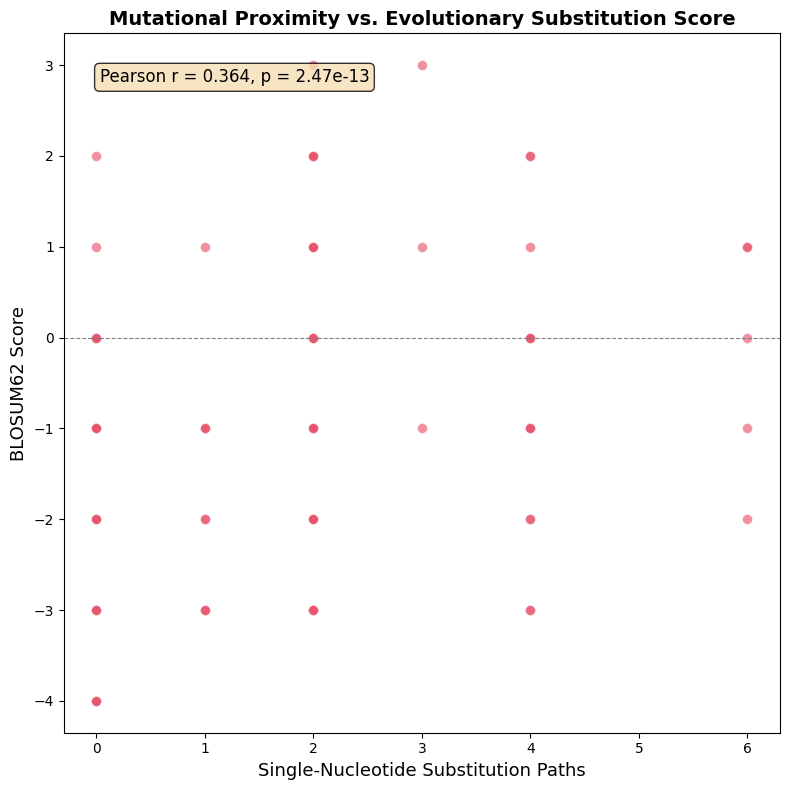

In [ ]:
from Bio.Align import substitution_matrices
from scipy import stats

blosum62 = substitution_matrices.load("BLOSUM62")

# Collect off-diagonal pairs
blosum_vals = []
sub_vals = []
for i, aa1 in enumerate(group_order):
    for j, aa2 in enumerate(group_order):
        if i != j:
            blosum_vals.append(blosum62[aa1, aa2])
            sub_vals.append(df_sub.loc[aa1, aa2])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sub_vals, blosum_vals, alpha=0.4, s=50, c="#E8546D", edgecolors="white", linewidth=0.5)
ax.set_xlabel("Single-Nucleotide Substitution Paths", fontsize=13)
ax.set_ylabel("BLOSUM62 Score", fontsize=13)
ax.set_title("Mutational Proximity vs. Evolutionary Substitution Score",
             fontsize=14, fontweight="bold")

r, p = stats.pearsonr(sub_vals, blosum_vals)
ax.text(0.05, 0.95, f"Pearson r = {r:.3f}, p = {p:.2e}",
        transform=ax.transAxes, fontsize=12, va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))

ax.axhline(y=0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()